Can i just go with a CSV like: 
sentence, gensim-tokens(using simple_preprocess, bio-tags-for-the-gensimtokens-column 
"I want Amul dark chocolate right now","I|want|Amul|dark|chocolate|right|now","O|O|B|I|I|O|O" 
So now the flow would be: for all the input sentences, first break them into gensim-tokens then create BIO column

Pipeline steps: 
Using Gensim tokenizer + word2vec:
0) We already have the gensim tokens in the data from previous steps
1) indexing (map tokens to indexes) (this is done using keras tokenizer) 
2) make lookup matrix: index -> word2vec vector

3) Now what, indeally i would have just converted entire sentence to indexes, passed to LSTM using mebedding layer and trained but now I want to go word by word and also append a dense layer and softmax head for BIO classes. I will use tensorflow and keras.
s
4) Train LSTM (use word2vec embedding layer), define no. of epochs and other hyperparameters,epochs, plot validation and training set loss per epoch : 
(i) Pass indexed sequences to LSTM, embedding layers convert word to vector using lookup matrix
5) Inference 

In [17]:
# Imports
import sklearn
import pandas as pd
import numpy as np

# Data Exploration

In [18]:
dataframe_original = pd.read_csv('./label_token_data_with_BIO_tags_v2.csv')
print(dataframe_original.head())
print(dataframe_original.describe())


                                            sentence  label  \
0    I want gift suggestion for general in all gifts      2   
1       I want gift suggestion for wife in all gifts      2   
2  Hi I need to send a birthday scroll to my youn...      2   
3                                           Birthday      2   
4  I want gift suggestion for general for love gifts      2   

                                              tokens  \
0      want|gift|suggestion|for|general|in|all|gifts   
1         want|gift|suggestion|for|wife|in|all|gifts   
2  hi|need|to|send|birthday|scroll|to|my|younger|...   
3                                           birthday   
4    want|gift|suggestion|for|general|for|love|gifts   

                      bio_tags  
0              O|B|O|O|O|O|O|B  
1              O|B|O|O|O|O|O|B  
2  O|O|O|O|B|I|O|O|O|O|O|O|O|O  
3                            O  
4              O|B|O|O|O|O|B|I  
        label
count  2157.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50

In [19]:
# Step 1: Validate and remove rows where token count != BIO tag count
def count_elements(row):
    """Count tokens and BIO tags in a row"""
    tokens = row['tokens'].split('|') if pd.notna(row['tokens']) else []
    tags = row['bio_tags'].split('|') if pd.notna(row['bio_tags']) else []
    return len(tokens), len(tags)

# Apply the function to each row
dataframe_original[['token_count', 'tag_count']] = dataframe_original.apply(
    lambda row: pd.Series(count_elements(row)), axis=1
)

# Check for mismatches
mismatch_count = (dataframe_original['token_count'] != dataframe_original['tag_count']).sum()
print(f"Rows with token-tag mismatch: {mismatch_count}")

if mismatch_count > 0:
    print(f"Removing {mismatch_count} rows with mismatched token/tag counts...")
    # Keep only rows where token count == tag count
    dataframe_clean = dataframe_original[
        dataframe_original['token_count'] == dataframe_original['tag_count']
    ].copy()
    print(f"Rows after validation: {len(dataframe_clean)}")
else:
    dataframe_clean = dataframe_original.copy()
    print("✓ All rows have matching token and tag counts!")

# Remove the helper columns
dataframe_clean = dataframe_clean.drop(['token_count', 'tag_count'], axis=1)

# Step 2: Filter dataframe - keep only rows with at least one 'B' or 'I' tag
# Discard rows where bio_tags column has all 'O' tags
def has_entity_tags(bio_tags_str):
    """Check if bio_tags string contains at least one 'B' or 'I' tag"""
    tags = bio_tags_str.split('|')
    return 'B' in tags or 'I' in tags

dataframe = dataframe_clean[dataframe_clean['bio_tags'].apply(has_entity_tags)].copy()

print(f"\nData Filtering Summary:")
print(f"  Original dataframe size: {len(dataframe_original)}")
print(f"  After removing mismatched rows: {len(dataframe_clean)}")
print(f"  After removing all 'O' tag rows: {len(dataframe)}")
print(f"  Total rows removed: {len(dataframe_original) - len(dataframe)}")
print(f"\nFiltered dataframe preview:")
print(dataframe.head())


Rows with token-tag mismatch: 235
Removing 235 rows with mismatched token/tag counts...
Rows after validation: 1922

Data Filtering Summary:
  Original dataframe size: 2157
  After removing mismatched rows: 1922
  After removing all 'O' tag rows: 1774
  Total rows removed: 383

Filtered dataframe preview:
                                            sentence  label  \
0    I want gift suggestion for general in all gifts      2   
1       I want gift suggestion for wife in all gifts      2   
2  Hi I need to send a birthday scroll to my youn...      2   
4  I want gift suggestion for general for love gifts      2   
5  I want gift suggestion for boyfriend for birthday      2   

                                              tokens  \
0      want|gift|suggestion|for|general|in|all|gifts   
1         want|gift|suggestion|for|wife|in|all|gifts   
2  hi|need|to|send|birthday|scroll|to|my|younger|...   
4    want|gift|suggestion|for|general|for|love|gifts   
5    want|gift|suggestion|for|boyf

Label Distribution:
label
2    1774
Name: count, dtype: int64

Total samples: 1774


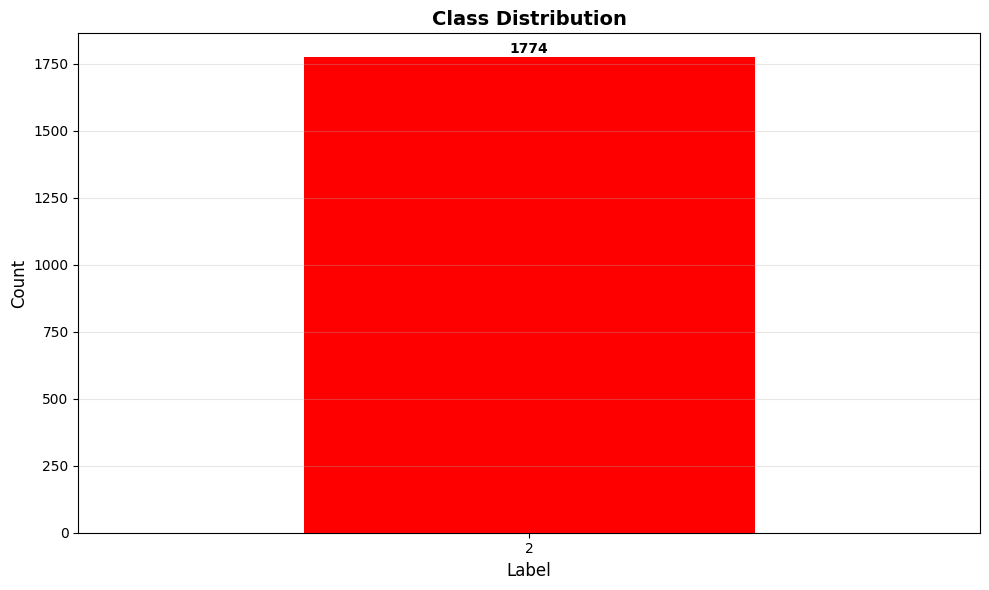


Label Meanings:
-2: Escalate to human agent
-1: Track order/order status (login required)
 1: General conversation/company policy
 2: Product recommendation


In [20]:
import matplotlib.pyplot as plt

# Count label distribution
label_counts = dataframe['label'].value_counts().sort_index()
print("Label Distribution:")
print(label_counts)
print(f"\nTotal samples: {len(dataframe)}")

# Create bar plot
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color=['red', 'orange', 'lightblue', 'green'])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print label meanings
print("\nLabel Meanings:")
print("-2: Escalate to human agent")
print("-1: Track order/order status (login required)")
print(" 1: General conversation/company policy")
print(" 2: Product recommendation")

# Pipeline

In [21]:
# Step 0: Preprocessing using gensim.simple_preprocess
# We already have gensim tokens in the 'tokens' column, so we can skip this step.

In [22]:
# Step 1: Indexing using Keras Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Parse the tokens column (tokens are stored as pipe-separated strings)
token_lists = dataframe['tokens'].apply(lambda x: x.split('|')).tolist()

print(f"Total sentences: {len(token_lists)}")
print(f"\nExample token lists (first 3):")
for i, tokens in enumerate(token_lists[:3]):
    print(f"  {i+1}. {tokens}")

# Initialize and fit the Keras Tokenizer on the token lists
# Note: We set filters='' to avoid removing any characters since tokens are pre-processed
# We set lower=False since tokens are already lowercased by gensim
tokenizer = Tokenizer(filters='', lower=False, oov_token='<OOV>')

# Fit on pre-tokenized data (pass as space-joined strings)
tokenized_texts = [' '.join(tokens) for tokens in token_lists]
tokenizer.fit_on_texts(tokenized_texts)

# Convert tokens to sequences of indices
sequences = tokenizer.texts_to_sequences(tokenized_texts)

# Get vocabulary info
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding index (0)
print(f"\n" + "=" * 80)
print("Tokenizer Information:")
print("=" * 80)
print(f"Vocabulary size (unique tokens): {len(tokenizer.word_index)}")
print(f"Vocabulary size (with padding): {vocab_size}")

# Show some examples from word_index
print(f"\nFirst 10 tokens in vocabulary (token -> index):")
for i, (word, idx) in enumerate(tokenizer.word_index.items()):
    if i < 10:
        print(f"  {word} -> {idx}")
    else:
        break

# Show sequence information
seq_lengths = [len(seq) for seq in sequences]
print(f"\n" + "=" * 80)
print("Sequence Information:")
print("=" * 80)
print(f"Total sequences: {len(sequences)}")
print(f"Min sequence length: {min(seq_lengths)}")
print(f"Max sequence length: {max(seq_lengths)}")
print(f"Average sequence length: {sum(seq_lengths) / len(seq_lengths):.2f}")

# Show example: tokens -> indices
print(f"\n" + "=" * 80)
print("Example Mappings (tokens -> indices):")
print("=" * 80)
for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"  Original tokens: {token_lists[i]}")
    print(f"  Indexed sequence: {sequences[i]}")
    print(f"  Sequence length: {len(sequences[i])}")


Total sentences: 1774

Example token lists (first 3):
  1. ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
  2. ['want', 'gift', 'suggestion', 'for', 'wife', 'in', 'all', 'gifts']
  3. ['hi', 'need', 'to', 'send', 'birthday', 'scroll', 'to', 'my', 'younger', 'brother', 'on', 'his', 'th', 'birthday']

Tokenizer Information:
Vocabulary size (unique tokens): 2883
Vocabulary size (with padding): 2884

First 10 tokens in vocabulary (token -> index):
  <OOV> -> 1
  and -> 2
  for -> 3
  to -> 4
  would -> 5
  it -> 6
  the -> 7
  want -> 8
  need -> 9
  with -> 10

Sequence Information:
Total sequences: 1774
Min sequence length: 1
Max sequence length: 101
Average sequence length: 11.18

Example Mappings (tokens -> indices):

Example 1:
  Original tokens: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
  Indexed sequence: [8, 20, 29, 3, 205, 24, 56, 77]
  Sequence length: 8

Example 2:
  Original tokens: ['want', 'gift', 'suggestion', 'for', 'wife

In [23]:
# Step 2: Load pretrained Word2Vec and build embedding lookup matrix
import gensim.downloader as api

# Load pretrained Word2Vec model (Google News, 300-dimensional vectors, 3M words)
# This is a famous pretrained model widely used in NLP applications
print("Loading pretrained Word2Vec model (Google News - 300d)...")
print("This may take a few minutes on first download...")
word2vec_model = api.load('word2vec-google-news-300')

print(f"\nPretrained Word2Vec model loaded:")
print(f"  Vocabulary size: {len(word2vec_model)} words")
print(f"  Embedding dimension: {word2vec_model.vector_size}")

# Create embedding matrix: index -> word2vec vector
# Matrix shape: (vocab_size + 1, embedding_dim)
# +1 because index 0 is reserved (for padding)
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = word2vec_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill the embedding matrix
words_found = 0
words_not_found = 0
words_not_found_list = []

for word, idx in tokenizer.word_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
        words_found += 1
    else:
        # Word not in word2vec vocabulary, leave as zeros or initialize randomly
        words_not_found += 1
        if words_not_found <= 10:  # Store first 10 missing words for display
            words_not_found_list.append(word)

print(f"\nEmbedding Matrix created:")
print(f"  Shape: {embedding_matrix.shape}")
print(f"  Vocabulary size (including padding): {vocab_size}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  Words found in pretrained Word2Vec: {words_found}")
print(f"  Words not found (initialized to zeros): {words_not_found}")
print(f"  Coverage: {100 * words_found / len(tokenizer.word_index):.2f}%")

if words_not_found_list:
    print(f"\n  First few missing words: {words_not_found_list}")

# Show example: word -> index -> vector
print("\n" + "-" * 80)
print("Example word embeddings (first 3 words found in pretrained model):")
print("-" * 80)
count = 0
for word, idx in tokenizer.word_index.items():
    if word in word2vec_model and count < 3:
        print(f"\nWord: '{word}'")
        print(f"Index: {idx}")
        print(f"Vector (first 10 dims): {embedding_matrix[idx][:10]}")
        print(f"Vector shape: {embedding_matrix[idx].shape}")
        count += 1
    if count >= 3:
        break

Loading pretrained Word2Vec model (Google News - 300d)...
This may take a few minutes on first download...

Pretrained Word2Vec model loaded:
  Vocabulary size: 3000000 words
  Embedding dimension: 300

Embedding Matrix created:
  Shape: (2884, 300)
  Vocabulary size (including padding): 2884
  Embedding dimension: 300
  Words found in pretrained Word2Vec: 2803
  Words not found (initialized to zeros): 80
  Coverage: 97.23%

  First few missing words: ['<OOV>', 'and', 'to', 'of', 'colour', 'personalised', 'grey', 'favourite', 'coloured', 'chromebook']

--------------------------------------------------------------------------------
Example word embeddings (first 3 words found in pretrained model):
--------------------------------------------------------------------------------

Word: 'for'
Index: 3
Vector (first 10 dims): [-0.01177979 -0.04736328  0.04467773  0.06347656 -0.01818848 -0.06396484
 -0.00131226 -0.07226562  0.06445312  0.08642578]
Vector shape: (300,)

Word: 'would'
Index: 

In [24]:
# Step 3: Pad sequences to have uniform length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine max sequence length
max_length = max(seq_lengths)
print(f"Maximum sequence length: {max_length}")

# Pad all sequences to max_length
# padding='post' adds zeros at the end
# truncating='post' truncates from the end if sequence is longer
padded_sequences = pad_sequences(
    sequences, 
    maxlen=max_length, 
    padding='post', 
    truncating='post'
)

print(f"\nPadded sequences shape: {padded_sequences.shape}")
print(f"  Number of samples: {padded_sequences.shape[0]}")
print(f"  Sequence length: {padded_sequences.shape[1]}")

# Show example of padding
print("\n" + "-" * 80)
print("Example of padding:")
print("-" * 80)
for i in range(2):
    print(f"\nOriginal sequence length: {len(sequences[i])}")
    print(f"Original: {sequences[i]}")
    print(f"Padded: {padded_sequences[i]}")
    print(f"Padded length: {len(padded_sequences[i])}")

Maximum sequence length: 101

Padded sequences shape: (1774, 101)
  Number of samples: 1774
  Sequence length: 101

--------------------------------------------------------------------------------
Example of padding:
--------------------------------------------------------------------------------

Original sequence length: 8
Original: [8, 20, 29, 3, 205, 24, 56, 77]
Padded: [  8  20  29   3 205  24  56  77   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0]
Padded length: 101

Original sequence length: 8
Original: [8, 20, 29, 3, 193, 24, 56, 77]
Padded: [  8  20  29   3 193  24  56  77   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0 

In [25]:
# Step 4: Build and Train LSTM Model for Entity Extraction (BIO Tagging)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, TimeDistributed, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("=" * 80)
print("Step 4: Preparing BIO Tags and Building LSTM Model")
print("=" * 80)

# Parse BIO tags from the dataframe
bio_tag_lists = dataframe['bio_tags'].apply(lambda x: x.split('|')).tolist()

print(f"\nTotal BIO tag sequences: {len(bio_tag_lists)}")
print(f"Example BIO tags (first 3):")
for i in range(3):
    print(f"  {i+1}. Tokens: {token_lists[i]}")
    print(f"     BIO tags: {bio_tag_lists[i]}")

# Create mapping: BIO tag string -> numeric label
bio_tag_to_id = {'O': 0, 'B': 1, 'I': 2}
id_to_bio_tag = {0: 'O', 1: 'B', 2: 'I'}
num_bio_classes = len(bio_tag_to_id)

print(f"\nBIO Tag Mapping:")
print(f"  {bio_tag_to_id}")
print(f"  Number of BIO classes: {num_bio_classes}")

# Convert BIO tags to numeric sequences
bio_sequences = []
for bio_tags in bio_tag_lists:
    bio_seq = [bio_tag_to_id[tag] for tag in bio_tags]
    bio_sequences.append(bio_seq)

# Pad BIO tag sequences to match input sequences
padded_bio_sequences = pad_sequences(
    bio_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post',
    value=0  # Pad with 'O' class
)

print(f"\nPadded BIO sequences shape: {padded_bio_sequences.shape}")

# Show example
print("\nExample of padded BIO sequences:")
for i in range(2):
    print(f"\n  Original tokens: {token_lists[i]}")
    print(f"  Original BIO tags: {bio_tag_lists[i]}")
    print(f"  Padded input sequence: {padded_sequences[i][:15]}...")
    print(f"  Padded BIO sequence: {padded_bio_sequences[i][:15]}...")

# Calculate class weights to handle imbalanced BIO tags
# Flatten all BIO sequences to count each class
all_bio_tags = padded_bio_sequences.flatten()
unique_classes = np.array([0, 1, 2])  # O, B, I

# Compute class weights using sklearn
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=all_bio_tags
)

# Create class weight dictionary
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("\n" + "=" * 80)
print("Class Weight Analysis:")
print("=" * 80)

# Count distribution
for i in range(num_bio_classes):
    count = np.sum(all_bio_tags == i)
    percentage = 100 * count / len(all_bio_tags)
    print(f"  Class {i} ({id_to_bio_tag[i]}): {count:,} samples ({percentage:.2f}%) - Weight: {class_weights[i]:.4f}")

print(f"\nTotal tags: {len(all_bio_tags):,}")
print("\nClass weights will emphasize B and I predictions during training!")

# Convert BIO sequences to one-hot encoding for categorical crossentropy
# Shape: (num_samples, max_length, num_bio_classes)
bio_sequences_categorical = to_categorical(padded_bio_sequences, num_classes=num_bio_classes)
print(f"\nCategorical BIO sequences shape: {bio_sequences_categorical.shape}")

# Create sample weights for each token position
# Shape: (num_samples, max_length)
# Each token gets a weight based on its BIO tag class
sample_weights = np.zeros((padded_bio_sequences.shape[0], max_length))
for i in range(padded_bio_sequences.shape[0]):
    for j in range(max_length):
        bio_tag_id = padded_bio_sequences[i, j]
        sample_weights[i, j] = class_weights[bio_tag_id]

print(f"\nSample weights shape: {sample_weights.shape}")
print(f"Sample weight stats:")
print(f"  Min: {sample_weights.min():.4f}")
print(f"  Max: {sample_weights.max():.4f}")
print(f"  Mean: {sample_weights.mean():.4f}")

# Split data into train and validation sets (including sample weights)
X_train, X_val, y_train, y_val, sw_train, sw_val = train_test_split(
    padded_sequences,
    bio_sequences_categorical,
    sample_weights,
    test_size=0.2,
    random_state=42
)

print(f"\nData Split:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Validation samples: {X_val.shape[0]}")
print(f"  Input shape: {X_train.shape}")
print(f"  Output shape: {y_train.shape}")

# Build LSTM model with TimeDistributed Dense layer for sequence labeling
print("\n" + "=" * 80)
print("Building LSTM Model Architecture")
print("=" * 80)

model = Sequential([
    # Embedding layer: use pretrained word2vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False,  # Freeze pretrained embeddings
        name='word2vec_embedding'
    ),
    
    # Bidirectional LSTM layer with return_sequences=True for token-level output
    # Bidirectional helps capture context from both directions
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_1'),
    
    # Another Bidirectional LSTM layer for deeper representation
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_2'),
    
    # TimeDistributed Dense layer: applies Dense layer to each timestep independently
    # This gives us a BIO prediction for each token in the sequence
    TimeDistributed(Dense(num_bio_classes, activation='softmax'), name='bio_classifier')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "=" * 80)
print("\nModel Architecture:")
print(model.summary())
print("Model built successfully!")
print("=" * 80)

Step 4: Preparing BIO Tags and Building LSTM Model

Total BIO tag sequences: 1774
Example BIO tags (first 3):
  1. Tokens: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
     BIO tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
  2. Tokens: ['want', 'gift', 'suggestion', 'for', 'wife', 'in', 'all', 'gifts']
     BIO tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
  3. Tokens: ['hi', 'need', 'to', 'send', 'birthday', 'scroll', 'to', 'my', 'younger', 'brother', 'on', 'his', 'th', 'birthday']
     BIO tags: ['O', 'O', 'O', 'O', 'B', 'I', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

BIO Tag Mapping:
  {'O': 0, 'B': 1, 'I': 2}
  Number of BIO classes: 3

Padded BIO sequences shape: (1774, 101)

Example of padded BIO sequences:

  Original tokens: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
  Original BIO tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
  Padded input sequence: [  8  20  29   3 205  24  56  77   0   0   0   0   0   0   0]...
  Padded

/Users/geetansh/Desktop/verve/chatbot/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding (Embedding)  │ ?                      │       865,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_classifier                  │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,200 (3.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 865,200 (3.30 MB)

None
Model built successfully!


In [26]:
# Step 5: Train the LSTM Model with Sample Weights
print("Training LSTM model for entity extraction...")
print("=" * 80)
print(f"Using class weights: {class_weights}")
print("Sample weights applied to each token position!")
print("This will emphasize B and I predictions and prevent the model from just predicting O!")
print("=" * 80)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model with sample weights
# BPTT (Backpropagation Through Time) is handled automatically by Keras/TensorFlow
# The LSTM will process sequences token-by-token and learn to predict BIO tags
# Sample weights penalize B and I misclassifications more heavily at each timestep
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val, sw_val),  # Include validation sample weights
    sample_weight=sw_train,  # Apply sample weights to emphasize B and I
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\n" + "=" * 80)
print("Training completed!")
print("=" * 80)

Training LSTM model for entity extraction...
Using class weights: {0: np.float64(0.3440479893698323), 1: np.float64(17.58676874754613), 2: np.float64(27.346459096459096)}
Sample weights applied to each token position!
This will emphasize B and I predictions and prevent the model from just predicting O!
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 337ms/step - accuracy: 0.8587 - loss: 0.6783 - val_accuracy: 0.8907 - val_loss: 0.5017
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.9014 - loss: 0.4645 - val_accuracy: 0.9167 - val_loss: 0.3541
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 503ms/step - accuracy: 0.9288 - loss: 0.3005 - val_accuracy: 0.9390 - val_loss: 0.2150
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 528ms/step - accuracy: 0.9557 - loss: 0.2310 - val_accuracy: 0.9618 - val_loss: 0.1874
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 521ms/step - accuracy: 0.9612 - loss: 0.1990 - val_accuracy: 0.9700 - val_loss: 0.1744
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 529ms/ste

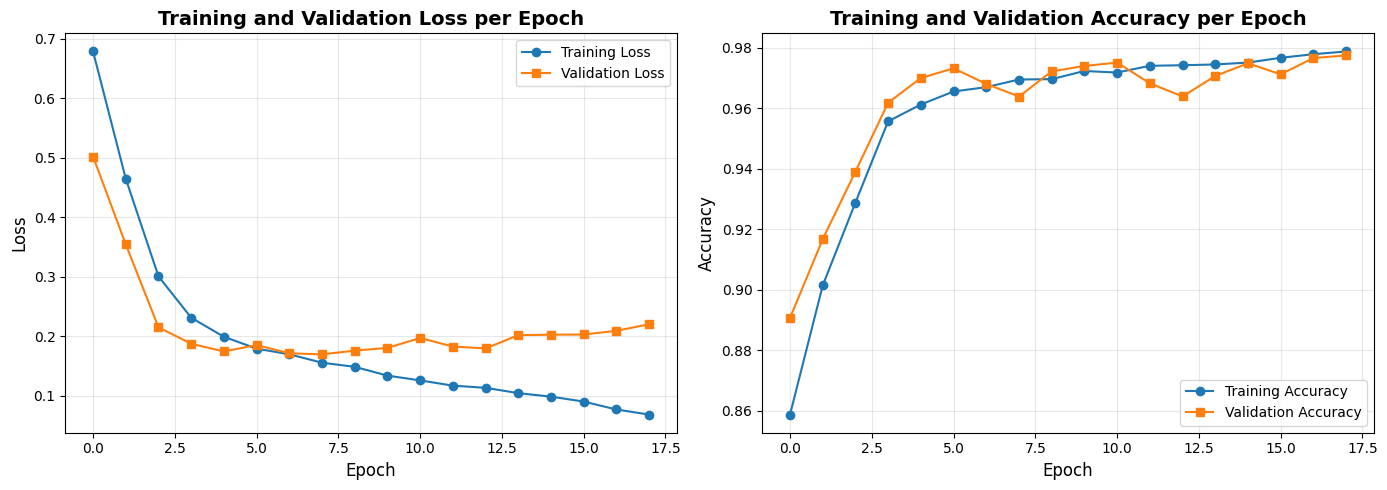


Final Training Metrics:
  Training Loss: 0.0684
  Training Accuracy: 0.9787
  Validation Loss: 0.2201
  Validation Accuracy: 0.9774


In [27]:
# Plot training and validation loss per epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss per Epoch', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"  Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [28]:
# Step 6: Inference Function for Entity Extraction
from gensim.utils import simple_preprocess

def extract_entities(sentence):
    """
    Extracts entities from a sentence using the trained LSTM model with BIO tagging.
    
    Args:
        sentence (str): Input sentence to extract entities from
    
    Returns:
        dict: Contains tokens, BIO predictions, and extracted entities
    """
    # Step 1: Preprocess the sentence (tokenize using gensim)
    tokens = simple_preprocess(sentence, deacc=True)
    
    if len(tokens) == 0:
        return {
            'sentence': sentence,
            'tokens': [],
            'bio_tags': [],
            'entities': []
        }
    
    # Step 2: Convert tokens to space-joined text for tokenizer
    preprocessed_text = ' '.join(tokens)
    
    # Step 3: Convert to sequence of indices
    sequence = tokenizer.texts_to_sequences([preprocessed_text])
    
    # Step 4: Pad the sequence
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Step 5: Make prediction
    predictions = model.predict(padded, verbose=0)  # Shape: (1, max_length, 3)
    
    # Step 6: Get predicted BIO tags for each token
    # Take argmax to get the class with highest probability
    predicted_bio_ids = np.argmax(predictions[0], axis=-1)  # Shape: (max_length,)
    
    # Convert IDs back to BIO tags (only for actual tokens, not padding)
    predicted_bio_tags = [id_to_bio_tag[bio_id] for bio_id in predicted_bio_ids[:len(tokens)]]
    
    # Step 7: Extract entities from BIO tags
    entities = []
    current_entity = []
    
    for i, (token, bio_tag) in enumerate(zip(tokens, predicted_bio_tags)):
        if bio_tag == 'B':  # Begin new entity
            if current_entity:  # Save previous entity if exists
                entities.append(' '.join(current_entity))
            current_entity = [token]
        elif bio_tag == 'I':  # Inside entity
            if current_entity:  # Continue current entity
                current_entity.append(token)
            else:  # I without B, treat as new entity (error recovery)
                current_entity = [token]
        else:  # bio_tag == 'O' (Outside entity)
            if current_entity:  # End current entity
                entities.append(' '.join(current_entity))
                current_entity = []
    
    # Don't forget the last entity if sentence ends with an entity
    if current_entity:
        entities.append(' '.join(current_entity))
    
    return {
        'sentence': sentence,
        'tokens': tokens,
        'bio_tags': predicted_bio_tags,
        'entities': entities,
        'token_tag_pairs': list(zip(tokens, predicted_bio_tags))
    }

print("Entity extraction function ready!")
print("\nUsage: extract_entities('your sentence here')")

# Test the inference function with example sentences
test_sentences = [
    "I want Amul dark chocolate right now",
    "I want gift suggestion for wife in all gifts",
    "Hi I need to send a birthday scroll to my younger brother",
    "I want gift suggestion for boyfriend for birthday",
    "Can you recommend a good smartphone under 20000 rupees",
    "I need Cadbury Dairy Milk and some flowers"
]

print("\n" + "=" * 80)
print("Testing Entity Extraction:")
print("=" * 80)

for sentence in test_sentences:
    result = extract_entities(sentence)
    print(f"\nSentence: {result['sentence']}")
    print(f"Tokens: {result['tokens']}")
    print(f"BIO Tags: {result['bio_tags']}")
    print(f"Token-Tag Pairs:")
    for token, tag in result['token_tag_pairs']:
        print(f"  {token:20s} -> {tag}")
    print(f"Extracted Entities: {result['entities']}")
    print("-" * 80)

Entity extraction function ready!

Usage: extract_entities('your sentence here')

Testing Entity Extraction:

Sentence: I want Amul dark chocolate right now
Tokens: ['want', 'amul', 'dark', 'chocolate', 'right', 'now']
BIO Tags: ['O', 'B', 'B', 'I', 'I', 'O']
Token-Tag Pairs:
  want                 -> O
  amul                 -> B
  dark                 -> B
  chocolate            -> I
  right                -> I
  now                  -> O
Extracted Entities: ['amul', 'dark chocolate right']
--------------------------------------------------------------------------------

Sentence: I want gift suggestion for wife in all gifts
Tokens: ['want', 'gift', 'suggestion', 'for', 'wife', 'in', 'all', 'gifts']
BIO Tags: ['O', 'B', 'O', 'O', 'B', 'O', 'O', 'B']
Token-Tag Pairs:
  want                 -> O
  gift                 -> B
  suggestion           -> O
  for                  -> O
  wife                 -> B
  in                   -> O
  all                  -> O
  gifts                ->

In [ ]:
# Interactive Entity Extraction
print("Interactive Entity Extraction")
print("=" * 80)
print("Enter sentences to extract entities. Type 'exit' to quit.\n")

while True:
    user_input = input("Enter a sentence: ")
    if user_input.lower() == 'exit':
        print("Exiting entity extraction.")
        break
    
    result = extract_entities(user_input)
    print(f"\nTokens and BIO Tags:")
    for token, tag in result['token_tag_pairs']:
        print(f"  {token:20s} -> {tag}")
    print(f"\nExtracted Entities: {result['entities']}")
    print("-" * 80)

Interactive Entity Extraction
Enter sentences to extract entities. Type 'exit' to quit.


Tokens and BIO Tags:
  do                   -> O
  you                  -> O
  guys                 -> B
  keep                 -> I
  leather              -> I
  shoes                -> I
  in                   -> O
  stck                 -> B
  during               -> O
  winters              -> B

Extracted Entities: ['guys keep leather shoes', 'stck', 'winters']
--------------------------------------------------------------------------------

Tokens and BIO Tags:
  do                   -> O
  you                  -> O
  guys                 -> B
  keep                 -> I
  leather              -> I
  shoes                -> I
  in                   -> O
  stock                -> B
  during               -> I
  winter               -> B

Extracted Entities: ['guys keep leather shoes', 'stock during', 'winter']
--------------------------------------------------------------------------------

T

# Save Model and Artifacts

In [ ]:
# Save the trained model and artifacts for entity extraction
import pickle

print("Saving model and artifacts...")
print("=" * 80)

# Save the model
model.save('lstm_entity_extraction.keras')
print("✓ Model saved as 'lstm_entity_extraction.keras'")

# Save the tokenizer
with open('entity_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved as 'entity_tokenizer.pkl'")

# Save model configuration and BIO mappings
model_config = {
    'max_length': max_length,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'num_bio_classes': num_bio_classes,
    'bio_tag_to_id': bio_tag_to_id,
    'id_to_bio_tag': id_to_bio_tag
}

with open('entity_model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)
print("✓ Model configuration saved as 'entity_model_config.pkl'")

print("\n" + "=" * 80)
print("All artifacts saved successfully!")
print("=" * 80)
print("\nSaved files:")
print("  1. lstm_entity_extraction.keras - Trained LSTM model")
print("  2. entity_tokenizer.pkl - Keras tokenizer")
print("  3. entity_model_config.pkl - Configuration and BIO mappings")

✓ Model saved as 'lstm_intent_classifier.keras'
✓ Tokenizer saved as 'tokenizer.pkl'
✓ Model configuration saved as 'model_config.pkl'

All artifacts saved successfully!


# Load Model and Run Inference (Fresh Start)

In [ ]:
# FRESH START: Load entity extraction model and run inference
# This code can be run in a fresh Python session/notebook

import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.utils import simple_preprocess

print("Loading saved entity extraction model and artifacts...")
print("=" * 80)

# Load the trained model
loaded_model = load_model('lstm_entity_extraction.keras')
print("✓ Model loaded from 'lstm_entity_extraction.keras'")

# Load the tokenizer
with open('entity_tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
print("✓ Tokenizer loaded from 'entity_tokenizer.pkl'")

# Load model configuration
with open('entity_model_config.pkl', 'rb') as f:
    loaded_config = pickle.load(f)
print("✓ Configuration loaded from 'entity_model_config.pkl'")

print("\nModel Configuration:")
print(f"  Max sequence length: {loaded_config['max_length']}")
print(f"  Vocabulary size: {loaded_config['vocab_size']}")
print(f"  Embedding dimension: {loaded_config['embedding_dim']}")
print(f"  Number of BIO classes: {loaded_config['num_bio_classes']}")
print(f"  BIO tag mapping: {loaded_config['bio_tag_to_id']}")
print("=" * 80)

Loading saved model and artifacts...
✓ Model loaded from 'lstm_intent_classifier.keras'
✓ Tokenizer loaded from 'tokenizer.pkl'
✓ Configuration loaded from 'model_config.pkl'

Model Configuration:
  Max sequence length: 33
  Vocabulary size: 1332
  Embedding dimension: 300


In [ ]:
# Define inference function using loaded artifacts
def extract_entities_from_loaded_model(sentence):
    """
    Extracts entities from a sentence using the loaded LSTM model.
    
    Args:
        sentence (str): Input sentence to extract entities from
    
    Returns:
        dict: Contains tokens, BIO predictions, and extracted entities
    """
    # Step 1: Preprocess the sentence (tokenize using gensim)
    tokens = simple_preprocess(sentence, deacc=True)
    
    if len(tokens) == 0:
        return {
            'sentence': sentence,
            'tokens': [],
            'bio_tags': [],
            'entities': []
        }
    
    # Step 2: Convert tokens to space-joined text for tokenizer
    preprocessed_text = ' '.join(tokens)
    
    # Step 3: Convert to sequence of indices
    sequence = loaded_tokenizer.texts_to_sequences([preprocessed_text])
    
    # Step 4: Pad the sequence
    padded = pad_sequences(
        sequence,
        maxlen=loaded_config['max_length'],
        padding='post',
        truncating='post'
    )
    
    # Step 5: Make prediction
    predictions = loaded_model.predict(padded, verbose=0)  # Shape: (1, max_length, 3)
    
    # Step 6: Get predicted BIO tags for each token
    predicted_bio_ids = np.argmax(predictions[0], axis=-1)
    
    # Convert IDs back to BIO tags (only for actual tokens)
    id_to_bio_tag = loaded_config['id_to_bio_tag']
    predicted_bio_tags = [id_to_bio_tag[bio_id] for bio_id in predicted_bio_ids[:len(tokens)]]
    
    # Step 7: Extract entities from BIO tags
    entities = []
    current_entity = []
    
    for i, (token, bio_tag) in enumerate(zip(tokens, predicted_bio_tags)):
        if bio_tag == 'B':  # Begin new entity
            if current_entity:
                entities.append(' '.join(current_entity))
            current_entity = [token]
        elif bio_tag == 'I':  # Inside entity
            if current_entity:
                current_entity.append(token)
            else:
                current_entity = [token]
        else:  # 'O' (Outside entity)
            if current_entity:
                entities.append(' '.join(current_entity))
                current_entity = []
    
    # Don't forget the last entity
    if current_entity:
        entities.append(' '.join(current_entity))
    
    return {
        'sentence': sentence,
        'tokens': tokens,
        'bio_tags': predicted_bio_tags,
        'entities': entities,
        'token_tag_pairs': list(zip(tokens, predicted_bio_tags))
    }

print("✓ Entity extraction function ready!")
print("\nUsage: extract_entities_from_loaded_model('your sentence here')")

✓ Inference function ready!

Usage: predict_intent_from_loaded_model('your sentence here')


In [ ]:
# Interactive Entity Extraction (using loaded model)
print("Interactive Entity Extraction (Loaded Model)")
print("=" * 80)
print("Enter sentences to extract entities. Type 'exit' to quit.\n")

while True:
    user_input = input("Enter a sentence: ")
    if user_input.lower() == 'exit':
        print("Exiting entity extraction.")
        break
    
    result = extract_entities_from_loaded_model(user_input)
    print(f"\nTokens and BIO Tags:")
    for token, tag in result['token_tag_pairs']:
        print(f"  {token:20s} -> {tag}")
    print(f"\nExtracted Entities: {result['entities']}")
    print("-" * 80)


Predicted Label: 1 - General conversation/company policy
Confidence: 91.45%
Probabilities:
  -2 (Escalate): 0.0473
  -1 (Track order): 0.0099
  1 (Conversation): 0.9145
  2 (Recommendation): 0.0283

Predicted Label: 1 - General conversation/company policy
Confidence: 91.83%
Probabilities:
  -2 (Escalate): 0.0466
  -1 (Track order): 0.0091
  1 (Conversation): 0.9183
  2 (Recommendation): 0.0259

Predicted Label: -1 - Track order/order status (login required)
Confidence: 93.92%
Probabilities:
  -2 (Escalate): 0.0034
  -1 (Track order): 0.9392
  1 (Conversation): 0.0566
  2 (Recommendation): 0.0008
Exiting inference loop.
